# 🛍️ Shopping Mall Customer Segmentation
## Member 1 — K-Means Clustering
**Dataset:** Shopping_Mall_Customer_Segmentation_Data_.csv  
**Algorithm:** K-Means Clustering  
**Task:** Unsupervised Machine Learning — Customer Segmentation

## 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Pre-processed Data
> Data was already cleaned and scaled in `step0_eda_preprocessing.ipynb`.


In [19]:
# Load preprocessed data from step0_eda_preprocessing.ipynb output
# ⚠️ Make sure you have run step0_eda_preprocessing.ipynb first!
import numpy as np
import pandas as pd

X_scaled = np.load('X_scaled.npy')
df_clean  = pd.read_csv('data/data_preprocessed.csv')
df        = pd.read_csv('data/Shopping Mall Customer Segmentation Data .csv')

print('✅ Loaded X_scaled.npy   shape:', X_scaled.shape)
print('✅ Loaded data_preprocessed.csv shape:', df_clean.shape)
print('✅ Loaded original CSV   shape:', df.shape)

✅ Loaded X_scaled.npy   shape: (15079, 4)
✅ Loaded data_preprocessed.csv shape: (15079, 4)
✅ Loaded original CSV   shape: (15079, 5)


## 2b. Re-fit Scaler
> Needed for transforming new customer input during prediction.

In [20]:
# Re-fit scaler on loaded data (needed for prediction inverse transform)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(df_clean)
print('✅ Scaler re-fitted on preprocessed data')

✅ Scaler re-fitted on preprocessed data


## 5. Find Optimal K — Elbow Method & Silhouette Score

In [5]:
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    print(f'K={k} | Inertia: {km.inertia_:.2f} | Silhouette: {silhouette_score(X_scaled, labels):.4f}')

K=2 | Inertia: 45236.12 | Silhouette: 0.2635
K=3 | Inertia: 39501.19 | Silhouette: 0.2225
K=4 | Inertia: 33831.97 | Silhouette: 0.2401
K=5 | Inertia: 30429.40 | Silhouette: 0.2331
K=6 | Inertia: 26911.87 | Silhouette: 0.2383
K=7 | Inertia: 24212.74 | Silhouette: 0.2475
K=8 | Inertia: 21417.91 | Silhouette: 0.2638
K=9 | Inertia: 19694.11 | Silhouette: 0.2668
K=10 | Inertia: 17935.47 | Silhouette: 0.2683


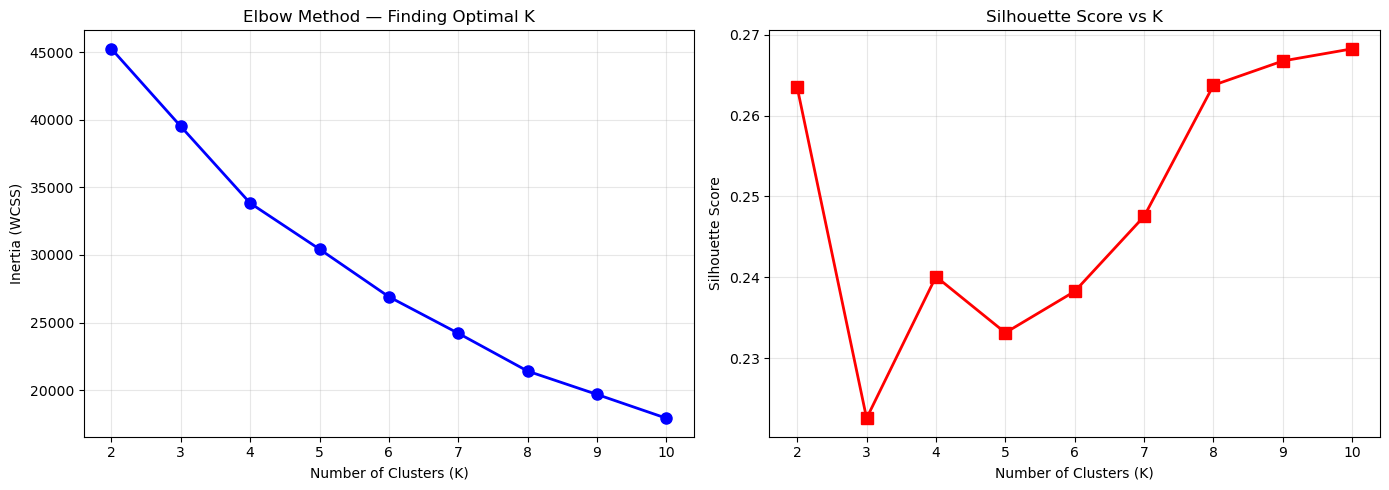

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method — Finding Optimal K')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouette_scores, 'rs-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=150)
plt.show()

## 6. Train Final K-Means Model

In [7]:
# Choose optimal K based on elbow + silhouette (adjust if needed)
OPTIMAL_K = silhouette_scores.index(max(silhouette_scores)) + 2
print(f'Optimal K selected: {OPTIMAL_K}')

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_clean['Cluster'] = cluster_labels
df['Cluster'] = cluster_labels

print('\nCluster Distribution:')
print(df['Cluster'].value_counts().sort_index())

Optimal K selected: 10

Cluster Distribution:
Cluster
0    1664
1    1563
2    1163
3    1309
4    1704
5    1273
6    1724
7    1625
8    1642
9    1412
Name: count, dtype: int64


## 7. Evaluation Metrics

In [8]:
sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)
inertia = kmeans.inertia_

print('=' * 45)
print('       K-MEANS EVALUATION METRICS')
print('=' * 45)
print(f'  Number of Clusters  : {OPTIMAL_K}')
print(f'  Inertia (WCSS)      : {inertia:.4f}')
print(f'  Silhouette Score    : {sil:.4f}  (closer to 1 = better)')
print(f'  Davies-Bouldin Index: {dbi:.4f}  (closer to 0 = better)')
print('=' * 45)

       K-MEANS EVALUATION METRICS
  Number of Clusters  : 10
  Inertia (WCSS)      : 17935.4739
  Silhouette Score    : 0.2683  (closer to 1 = better)
  Davies-Bouldin Index: 1.0594  (closer to 0 = better)


## 8. Cluster Visualization (PCA 2D)

Explained Variance by 2 PCA components: 50.32%


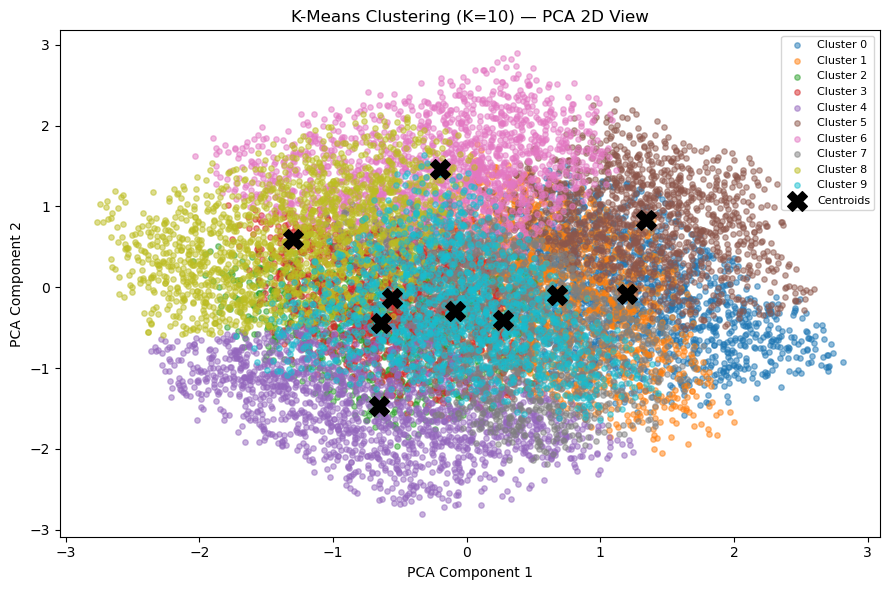

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f'Explained Variance by 2 PCA components: {pca.explained_variance_ratio_.sum()*100:.2f}%')

plt.figure(figsize=(9, 6))
palette = sns.color_palette('tab10', OPTIMAL_K)
for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=palette[c], label=f'Cluster {c}', alpha=0.5, s=15)

# Plot centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            marker='X', s=200, c='black', zorder=5, label='Centroids')

plt.title(f'K-Means Clustering (K={OPTIMAL_K}) — PCA 2D View')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.savefig('kmeans_pca_clusters.png', dpi=150)
plt.show()

## 9. Cluster Profile Analysis

In [10]:
profile = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean().round(2)
profile['Count'] = df.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(2)
print('Cluster Profiles:')
profile

Cluster Profiles:


,Age,Annual Income,Spending Score,Count,% of Total
Cluster,,,,,
0,53.12,60114.37,75.59,1664,11.04
1,37.04,128290.30,78.62,1563,10.37
2,35.73,152097.97,25.70,1163,7.71
3,72.32,70853.94,25.93,1309,8.68
4,49.74,57243.91,27.99,1704,11.30
5,35.48,151006.71,74.32,1273,8.44
6,73.50,156923.26,53.90,1724,11.43
7,35.06,108772.30,23.66,1625,10.78
8,74.66,152725.09,42.60,1642,10.89


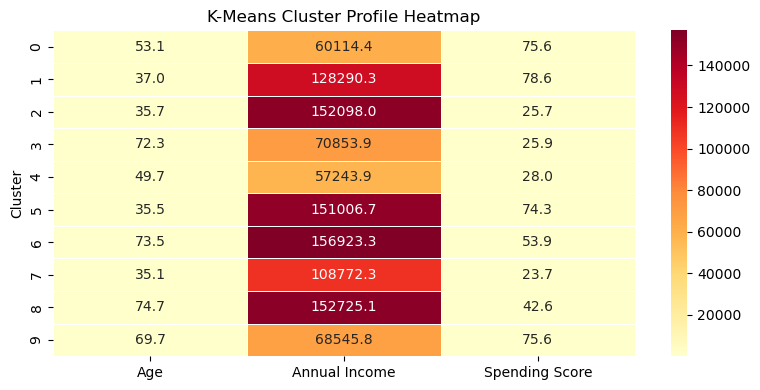

In [11]:
# Heatmap of cluster profiles
plt.figure(figsize=(8, 4))
heatmap_data = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean()
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title('K-Means Cluster Profile Heatmap')
plt.tight_layout()
plt.savefig('kmeans_heatmap.png', dpi=150)
plt.show()

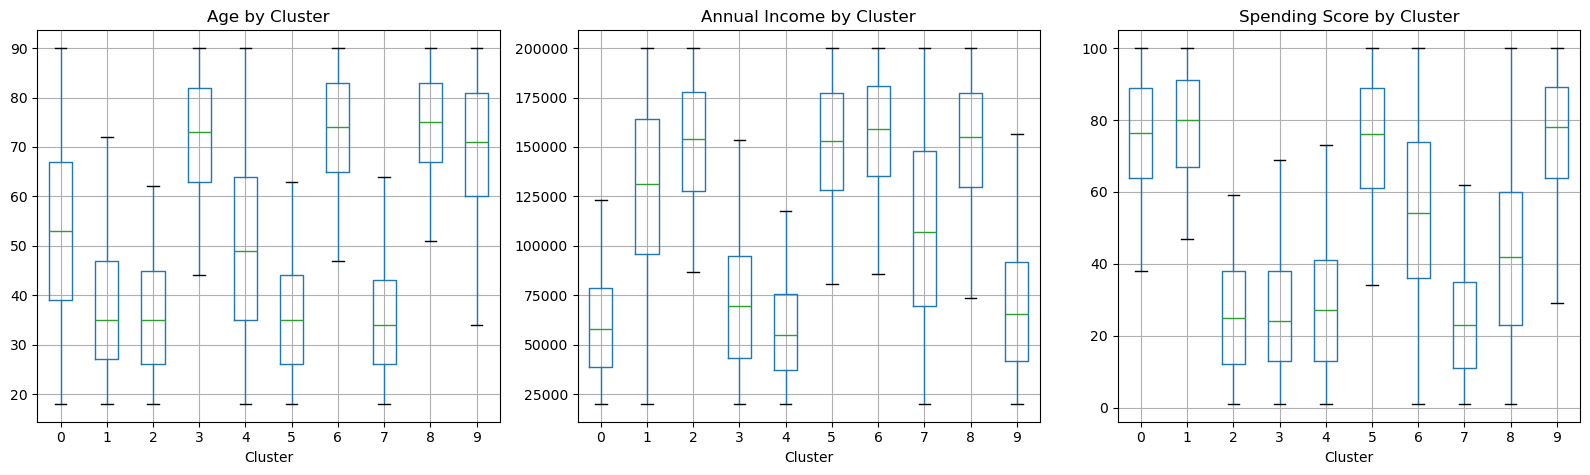

In [12]:
# Box plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
features = ['Age', 'Annual Income', 'Spending Score']
colors_box = sns.color_palette('tab10', OPTIMAL_K)

for i, feat in enumerate(features):
    df.boxplot(column=feat, by='Cluster', ax=axes[i])
    axes[i].set_title(f'{feat} by Cluster')
    axes[i].set_xlabel('Cluster')

plt.suptitle('')
plt.tight_layout()
plt.savefig('kmeans_boxplots.png', dpi=150)
plt.show()

## 10. Summary

In [13]:
print('=' * 55)
print('         K-MEANS CLUSTERING — FINAL SUMMARY')
print('=' * 55)
print(f'  Algorithm           : K-Means')
print(f'  Optimal K           : {OPTIMAL_K}')
print(f'  Total Customers     : {len(df)}')
print(f'  Inertia (WCSS)      : {inertia:.4f}')
print(f'  Silhouette Score    : {sil:.4f}')
print(f'  Davies-Bouldin Index: {dbi:.4f}')
print('=' * 55)
print('\nCluster Sizes:')
for c, count in df['Cluster'].value_counts().sort_index().items():
    pct = count / len(df) * 100
    print(f'  Cluster {c}: {count} customers ({pct:.1f}%)')

         K-MEANS CLUSTERING — FINAL SUMMARY
  Algorithm           : K-Means
  Optimal K           : 10
  Total Customers     : 15079
  Inertia (WCSS)      : 17935.4739
  Silhouette Score    : 0.2683
  Davies-Bouldin Index: 1.0594

Cluster Sizes:
  Cluster 0: 1664 customers (11.0%)
  Cluster 1: 1563 customers (10.4%)
  Cluster 2: 1163 customers (7.7%)
  Cluster 3: 1309 customers (8.7%)
  Cluster 4: 1704 customers (11.3%)
  Cluster 5: 1273 customers (8.4%)
  Cluster 6: 1724 customers (11.4%)
  Cluster 7: 1625 customers (10.8%)
  Cluster 8: 1642 customers (10.9%)
  Cluster 9: 1412 customers (9.4%)


---
# 🔮 Predict Customer Segment
> Enter a new customer's details below and the trained model will predict which segment they belong to.

In [21]:
# ============================================================
#  ✏️  ENTER CUSTOMER DETAILS HERE
# ============================================================
input_age           = int(input('Enter Age           : '))
input_gender        = input('Enter Gender        (Male/Female): ').strip().capitalize()
input_annual_income = float(input('Enter Annual Income : '))
input_spending_score= float(input('Enter Spending Score (1-100): '))

# Encode gender
gender_encoded = 0 if input_gender == 'Female' else 1

# Build input array and scale it
new_customer = np.array([[input_age, gender_encoded, input_annual_income, input_spending_score]])
new_customer_scaled = scaler.transform(new_customer)

# Predict cluster
predicted_cluster = kmeans.predict(new_customer_scaled)[0]

# Get cluster profile for context
cluster_profile = df[df['Cluster'] == predicted_cluster][['Age','Annual Income','Spending Score']].mean()
cluster_size    = (df['Cluster'] == predicted_cluster).sum()

print()
print('=' * 55)
print('         K-MEANS — PREDICTION RESULT')
print('=' * 55)
print(f'  Input  → Age: {input_age}, Gender: {input_gender}')
print(f'           Annual Income: {input_annual_income:,.0f}')
print(f'           Spending Score: {input_spending_score}')
print()
print(f'  ✅ Predicted Cluster : {predicted_cluster}')
print(f'  👥 Cluster Size      : {cluster_size} customers')
print()
print('  Cluster Average Profile:')
print(f'    Average Age          : {cluster_profile["Age"]:.1f}')
print(f'    Average Annual Income: {cluster_profile["Annual Income"]:,.0f}')
print(f'    Average Spending Score: {cluster_profile["Spending Score"]:.1f}')
print('=' * 55)

Enter Age           :  20
Enter Gender        (Male/Female):  male
Enter Annual Income :  15000
Enter Spending Score (1-100):  2


KeyError: 'Cluster'

In [18]:
# Visualise the new customer on the PCA cluster plot
new_pca = pca.transform(new_customer_scaled)

plt.figure(figsize=(9, 6))
palette = sns.color_palette('tab10', OPTIMAL_K)
for c in range(OPTIMAL_K):
    mask = cluster_labels == c
    lbl = f'Cluster {c} ← YOU' if c == predicted_cluster else f'Cluster {c}'
    alpha = 0.6 if c == predicted_cluster else 0.25
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                color=palette[c], label=lbl, alpha=alpha, s=15)

plt.scatter(new_pca[0, 0], new_pca[0, 1],
            marker='*', s=500, color='black', zorder=10, label='New Customer')

plt.title(f'K-Means — New Customer falls in Cluster {predicted_cluster}', fontweight='bold')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.savefig('kmeans_prediction.png', dpi=150)
plt.show()

NameError: name 'new_customer_scaled' is not defined